In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df= pd.read_csv("/content/pizza_sales.csv")
df.head(10)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
5,6,2,thai_ckn_l,1,01-01-2015,11:57:40,20.75,20.75,L,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza
6,7,3,ital_supr_m,1,01-01-2015,12:12:28,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
7,8,3,prsc_argla_l,1,01-01-2015,12:12:28,20.75,20.75,L,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",The Prosciutto and Arugula Pizza
8,9,4,ital_supr_m,1,01-01-2015,12:16:31,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
9,10,5,ital_supr_m,1,01-01-2015,12:21:30,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [ ]:
df.isnull().sum()

,0
pizza_id,0
order_id,0
pizza_name_id,0
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,0
pizza_size,0
pizza_category,0


In [ ]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"], format="%d-%m-%Y")


In [ ]:
df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [ ]:
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')
def extract(a):
  hours= a.hour
  if hours<12:
    return "Morning"
  elif hours>=12 and hours<17:
    return "afternoon"
  elif hours >=17 and hours <=20:
    return "evening"
  else:
    return "night"
df["time"]=df["order_time"].apply(extract)
df["time"]

,time
0,Morning
1,Morning
2,Morning
3,Morning
4,Morning
...,...
48615,night
48616,night
48617,night
48618,night


In [20]:
x=df.groupby("pizza_name",as_index=False)["total_price"].sum().nlargest(10,"total_price")
x

,pizza_name,total_price
30,The Thai Chicken Pizza,43434.25
0,The Barbecue Chicken Pizza,42768.00
4,The California Chicken Pizza,41409.50
7,The Classic Deluxe Pizza,38180.50
26,The Spicy Italian Pizza,34831.25
25,The Southwest Chicken Pizza,34705.75
14,The Italian Supreme Pizza,33476.75
12,The Hawaiian Pizza,32273.25
9,The Four Cheese Pizza,32265.70
23,The Sicilian Pizza,30940.50


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'The Thai Chicken Pizza'),
  Text(1, 0, 'The Barbecue Chicken Pizza'),
  Text(2, 0, 'The California Chicken Pizza'),
  Text(3, 0, 'The Classic Deluxe Pizza'),
  Text(4, 0, 'The Spicy Italian Pizza'),
  Text(5, 0, 'The Southwest Chicken Pizza'),
  Text(6, 0, 'The Italian Supreme Pizza'),
  Text(7, 0, 'The Hawaiian Pizza'),
  Text(8, 0, 'The Four Cheese Pizza'),
  Text(9, 0, 'The Sicilian Pizza')])

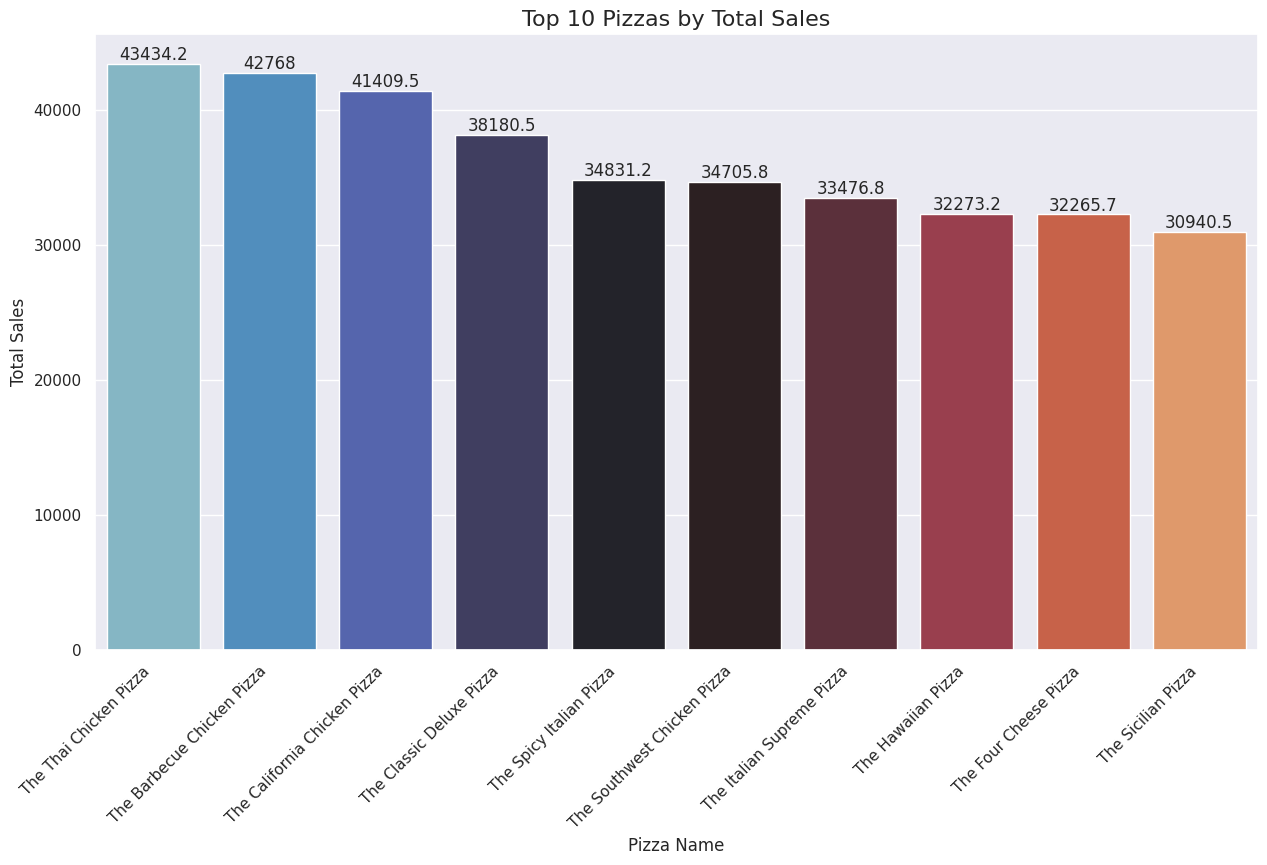

In [68]:
sns.set(rc={"figure.figsize":(15,8)})
r=sns.barplot(data=x,x="pizza_name",y="total_price",hue="pizza_name",palette="icefire", legend=False)
for i in r.containers:
  r.bar_label(i)
plt.title('Top 10 Pizzas by Total Sales', fontsize=16)
plt.xlabel('Pizza Name', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')

In [29]:
y=df.groupby("time",as_index=False)["total_price"].sum()
y

,time,total_price
0,Morning,45322.45
1,afternoon,400192.70
2,evening,306378.60
3,night,65966.30


Text(0, 0.5, 'Total Sales')

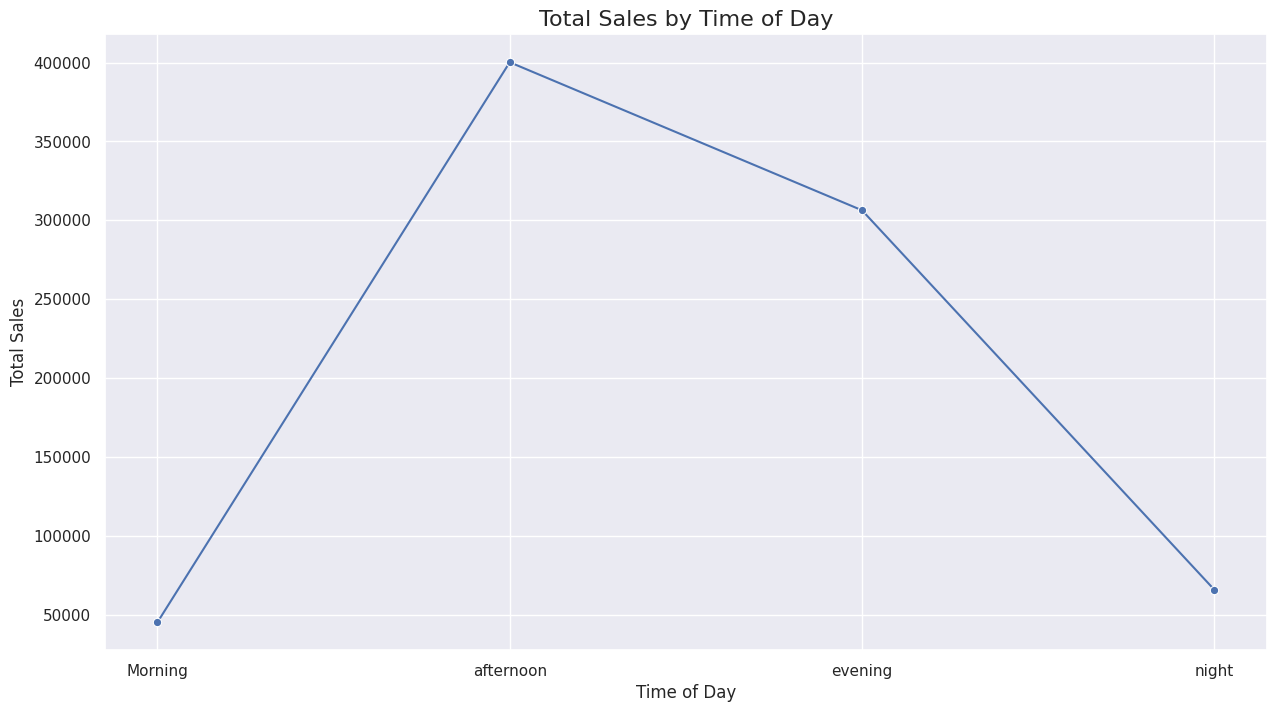

In [69]:
sns.set(rc={"figure.figsize":(15,8)})
sns.lineplot(data=y,x="time",y="total_price",marker="o")
plt.title('Total Sales by Time of Day', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

In [35]:
t=df.groupby(["pizza_category","time"],as_index=False)["total_price"].sum()
t

,pizza_category,time,total_price
0,Chicken,Morning,10591.50
1,Chicken,afternoon,95356.75
2,Chicken,evening,73676.50
3,Chicken,night,16294.75
4,Classic,Morning,12909.85
5,Classic,afternoon,107577.30
6,Classic,evening,82160.30
7,Classic,night,17405.65
8,Supreme,Morning,11836.90
9,Supreme,afternoon,101815.15


Text(0, 0.5, 'Total Sales')

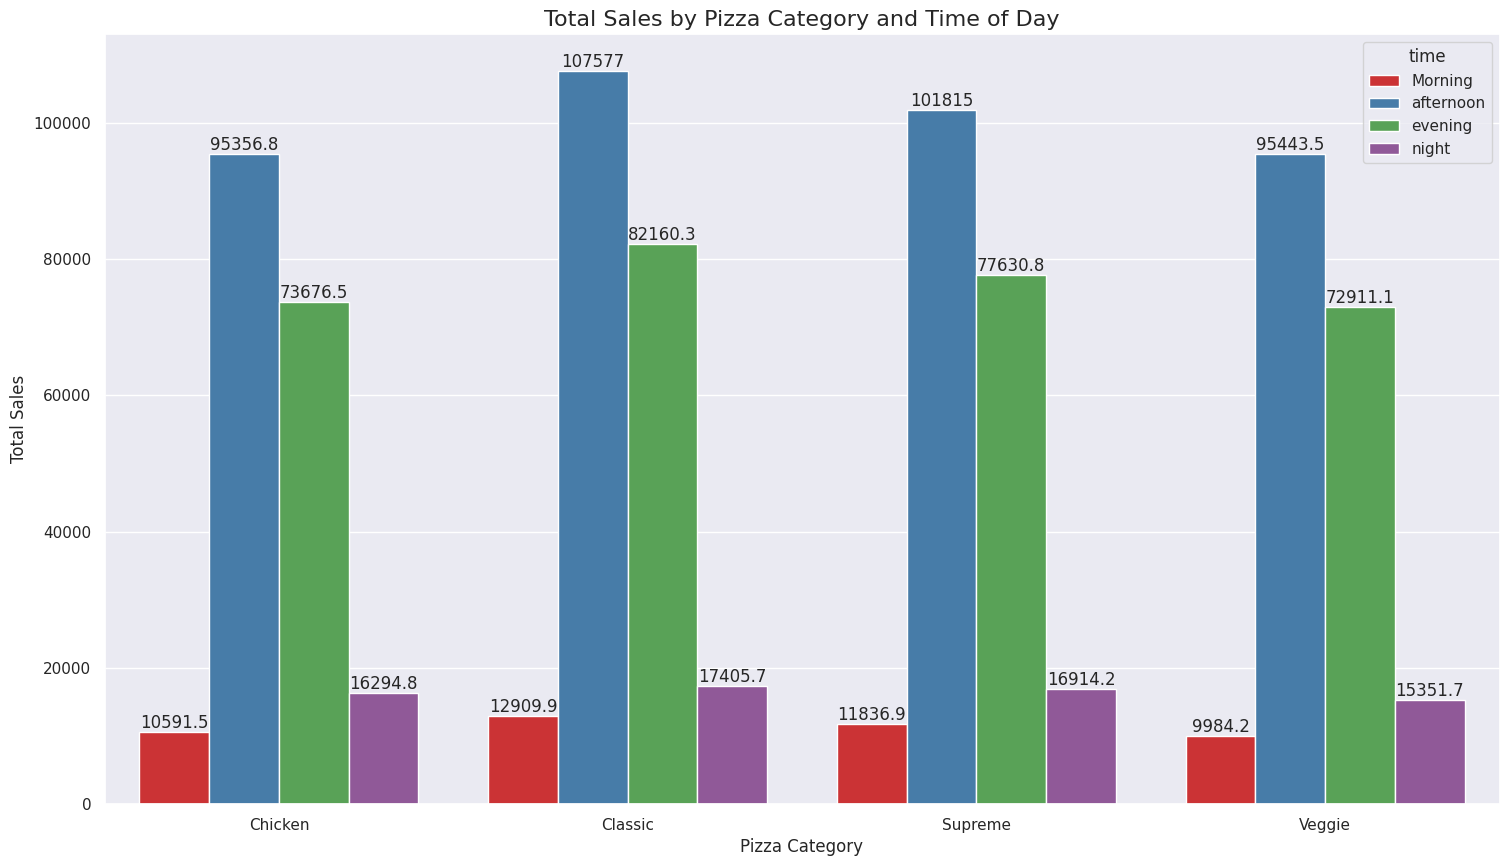

In [71]:
sns.set(rc={"figure.figsize":(18,10)})
c=sns.barplot(data=t,x="pizza_category",y="total_price",hue="time",palette="Set1")
for i in c.containers:
  c.bar_label(i)
plt.title('Total Sales by Pizza Category and Time of Day', fontsize=16)
plt.xlabel('Pizza Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

<Axes: xlabel='pizza_category', ylabel='total_price'>

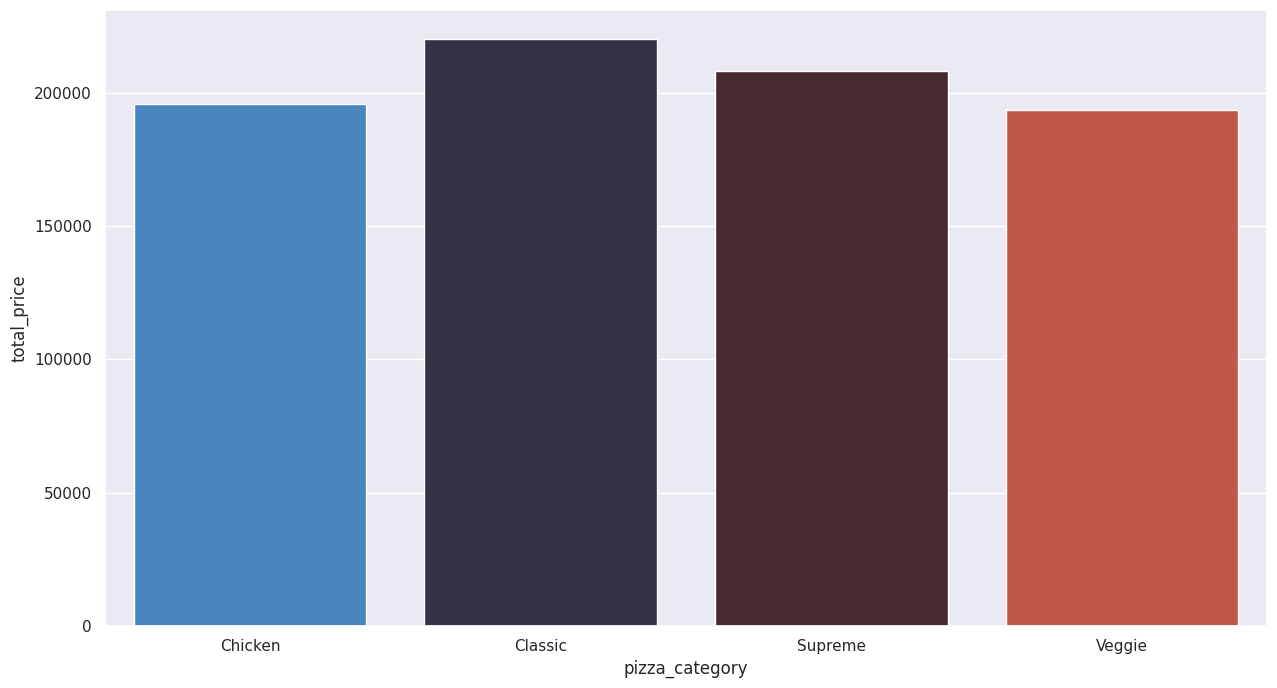

In [40]:
t_cat = t.groupby("pizza_category", as_index=False)["total_price"].sum()
sns.barplot(data=t_cat, x="pizza_category", y="total_price", hue="pizza_category", palette="icefire", legend=False)

In [54]:
df["month"]=df["order_date"].dt.strftime("%b")
df["month"]

,month
0,Jan
1,Jan
2,Jan
3,Jan
4,Jan
...,...
48615,Dec
48616,Dec
48617,Dec
48618,Dec


In [55]:
p=df.groupby("month",as_index=False)["total_price"].sum()
p

,month,total_price
0,Apr,68736.80
1,Aug,68278.25
2,Dec,64701.15
3,Feb,65159.60
4,Jan,69793.30
5,Jul,72557.90
6,Jun,68230.20
7,Mar,70397.10
8,May,71402.75
9,Nov,70395.35


Text(0, 0.5, 'Total Sales')

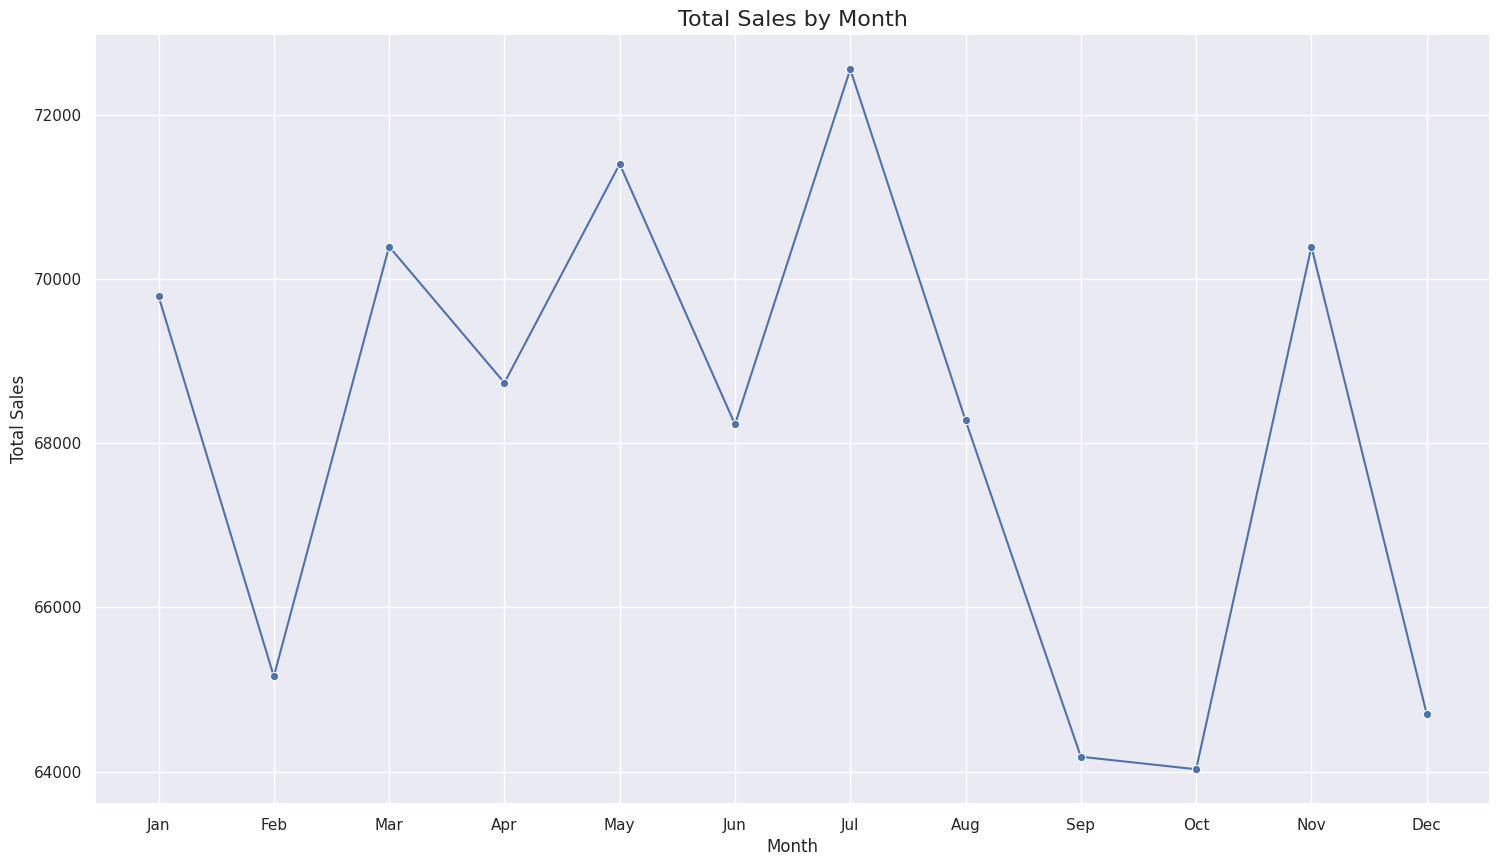

In [75]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
p['month'] = pd.Categorical(p['month'], categories=month_order, ordered=True)
p = p.sort_values('month')

sns.lineplot(data=p,x="month",y="total_price",marker="o")
plt.title('Total Sales by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

In [66]:
f=df.groupby(["pizza_size","pizza_category"],as_index=False)["total_price"].sum()
f=f[(f["pizza_size"]!="XL") & (f["pizza_size"]!="XXL")]
f

,pizza_size,pizza_category,total_price
0,L,Chicken,102339.00
1,L,Classic,74518.50
2,L,Supreme,94258.50
3,L,Veggie,104202.70
4,M,Chicken,65224.50
5,M,Classic,60581.75
6,M,Supreme,66475.00
7,M,Veggie,57101.00
8,S,Chicken,28356.00
9,S,Classic,69870.25


Text(0, 0.5, 'Total Sales')

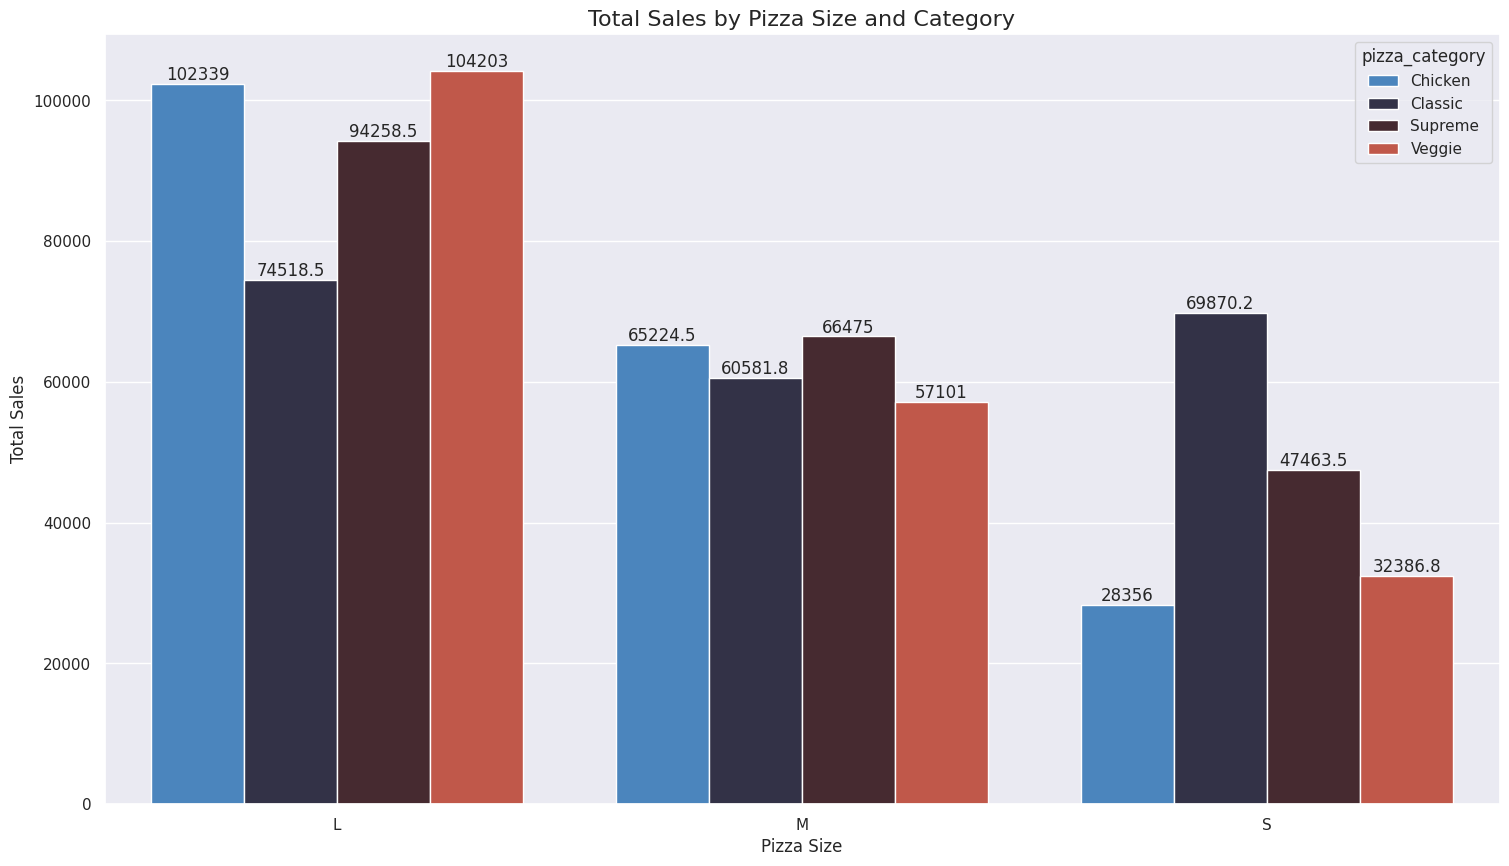

In [74]:
o=sns.barplot(data=f,x="pizza_size",y="total_price",hue="pizza_category",palette="icefire")
for i in o.containers:
  o.bar_label(i)
plt.title('Total Sales by Pizza Size and Category', fontsize=16)
plt.xlabel('Pizza Size', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

## Conclusion of Pizza Sales Analysis

This analysis has provided valuable insights into the pizza sales data, revealing several key trends and performance indicators:

*   **Top-Performing Pizzas**: The 'Thai Chicken Pizza', 'Barbecue Chicken Pizza', and 'California Chicken Pizza' emerged as the top three highest-grossing pizzas, indicating customer preferences and potential areas for marketing focus.
*   **Sales by Time of Day**: Sales peak significantly in the **afternoon**, followed by the **evening**, with mornings and nights showing comparatively lower sales. This suggests that marketing efforts or staffing could be optimized around these peak hours.
*   **Monthly Sales Trends**: The total sales exhibit fluctuations throughout the year, with **July** showing the highest sales, followed by May and March. October and September tend to be the lowest performing months. This seasonality can help in inventory management and promotional planning.
*   **Pizza Categories**: While the overall sales are strong across Chicken, Classic, Supreme, and Veggie categories, we observed how each category contributes to sales during different times of the day. The **Classic** category generally leads in total sales, followed closely by Supreme, Chicken, and Veggie.
*   **Pizza Size Performance**: Large (L) sized pizzas contribute the most to total sales across all categories, with Medium (M) and Small (S) sizes also showing substantial revenue. Understanding the demand for different sizes can inform pricing strategies and ingredient purchasing.

Overall, the analysis highlights predictable patterns in sales based on pizza type, time of day, month, and size. These insights can be leveraged to make informed business decisions, such as optimizing menu offerings, adjusting operational hours, planning promotions, and managing inventory more effectively.